In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.stats import entropy as scipy_entropy

print("Information Theory — Derin Öğrenmenin Gizli Temeli")
print("=" * 50)
print()
print("Bugün cevaplayacağımız sorular:")
print("1. Entropy nedir — belirsizliği nasıl ölçeriz?")
print("2. Cross Entropy neden loss fonksiyonu?")
print("3. KL Divergence — iki dağılım ne kadar farklı?")
print("4. Mutual Information — değişkenler ne kadar ilişkili?")
print("5. Bunların derin öğrenmedeki yeri neresi?")
print()
print("Anahtar: Bilgi = Sürpriz!")

np.random.seed(42)

Information Theory — Derin Öğrenmenin Gizli Temeli

Bugün cevaplayacağımız sorular:
1. Entropy nedir — belirsizliği nasıl ölçeriz?
2. Cross Entropy neden loss fonksiyonu?
3. KL Divergence — iki dağılım ne kadar farklı?
4. Mutual Information — değişkenler ne kadar ilişkili?
5. Bunların derin öğrenmedeki yeri neresi?

Anahtar: Bilgi = Sürpriz!


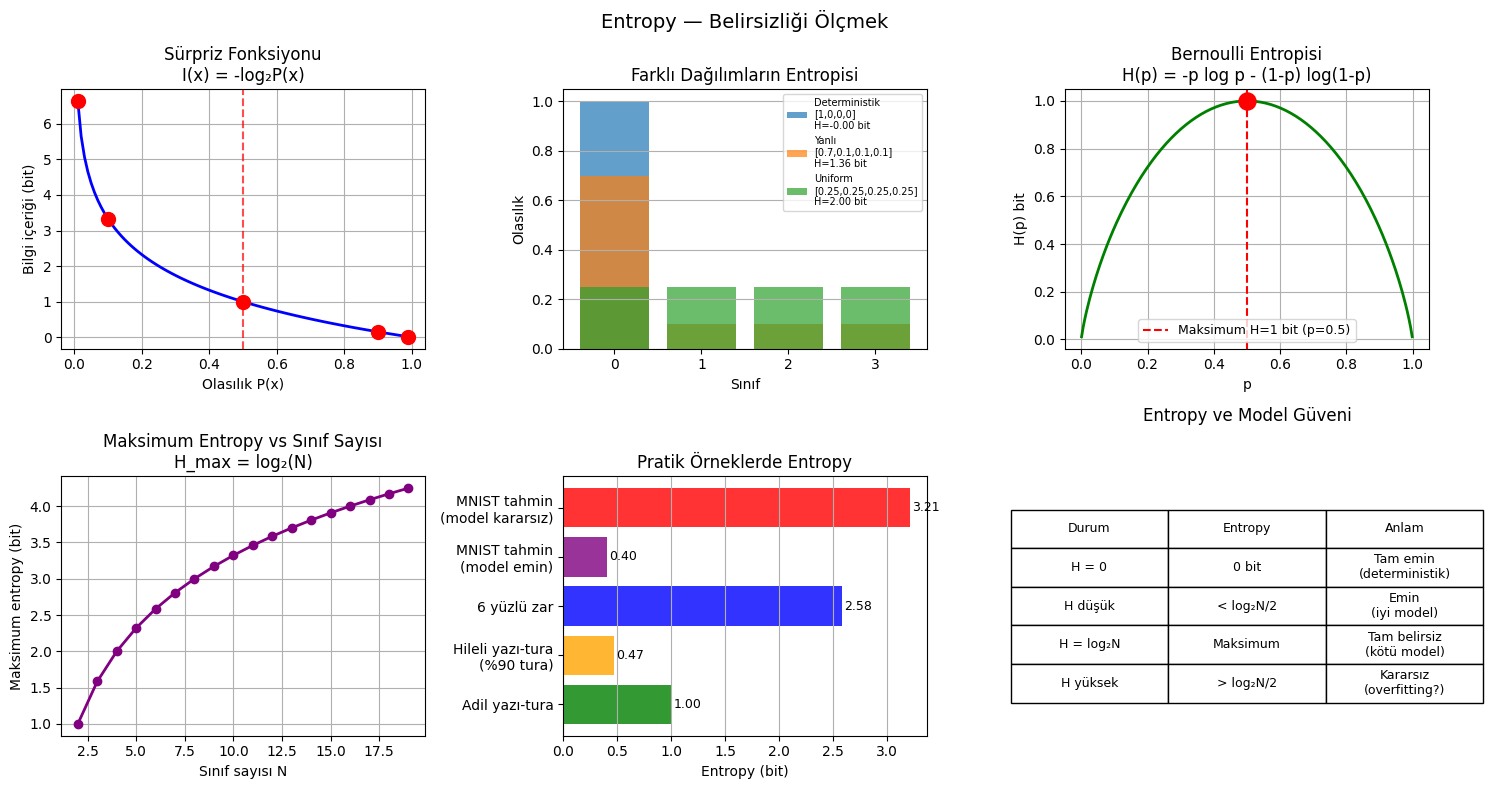

Temel sonuçlar:
Deterministik dağılım entropisi: -0.0000 bit
Uniform (4 sınıf) entropisi:     2.0000 bit
Maksimum teorik (4 sınıf):       2.0000 bit


In [2]:
# ENTROPY — BELİRSİZLİĞİ ÖLÇMEK
#
# Soru: Bir olayın "bilgi değeri" ne kadar?
# Cevap: Ne kadar sürpriz olursa o kadar bilgi taşır!
#
# "Güneş doğdu" → az bilgi (beklenen)
# "Deprem oldu" → çok bilgi (sürpriz)
#
# Matematiksel tanım:
# I(x) = -log₂ P(x)    ← bir olayın bilgi içeriği (bit)
# H(X) = -Σ P(x)*log P(x)  ← dağılımın entropisi

# Sürpriz fonksiyonu
p_range = np.linspace(0.01, 0.99, 100)
surprise = -np.log2(p_range)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Sürpriz fonksiyonu
axes[0,0].plot(p_range, surprise, 'b-', linewidth=2)
axes[0,0].axvline(x=0.5, color='red', linestyle='--', alpha=0.7)
axes[0,0].scatter([0.01, 0.1, 0.5, 0.9, 0.99],
                  [-np.log2(p) for p in [0.01, 0.1, 0.5, 0.9, 0.99]],
                  color='red', s=100, zorder=5)
axes[0,0].set_title("Sürpriz Fonksiyonu\nI(x) = -log₂P(x)")
axes[0,0].set_xlabel("Olasılık P(x)")
axes[0,0].set_ylabel("Bilgi içeriği (bit)")
axes[0,0].grid(True)

# Farklı dağılımların entropisi
dağılımlar = {
    'Deterministik\n[1,0,0,0]': np.array([1.0, 0.0, 0.0, 0.0]),
    'Yanlı\n[0.7,0.1,0.1,0.1]': np.array([0.7, 0.1, 0.1, 0.1]),
    'Uniform\n[0.25,0.25,0.25,0.25]': np.array([0.25, 0.25, 0.25, 0.25]),
}

def entropy(p, eps=1e-10):
    p = np.array(p)
    return -np.sum(p * np.log2(p + eps))

for i, (isim, dist) in enumerate(dağılımlar.items()):
    H = entropy(dist)
    axes[0,1].bar(range(len(dist)), dist,
                 alpha=0.7, label=f'{isim}\nH={H:.2f} bit')

axes[0,1].set_title("Farklı Dağılımların Entropisi")
axes[0,1].set_xlabel("Sınıf")
axes[0,1].set_ylabel("Olasılık")
axes[0,1].legend(fontsize=7)
axes[0,1].grid(True, axis='y')

# Bernoulli entropisi
p_vals = np.linspace(0.001, 0.999, 200)
H_bernoulli = -(p_vals * np.log2(p_vals) + (1-p_vals) * np.log2(1-p_vals))

axes[0,2].plot(p_vals, H_bernoulli, 'g-', linewidth=2)
axes[0,2].axvline(x=0.5, color='red', linestyle='--',
                  label='Maksimum H=1 bit (p=0.5)')
axes[0,2].scatter([0.5], [1.0], color='red', s=150, zorder=5)
axes[0,2].set_title("Bernoulli Entropisi\nH(p) = -p log p - (1-p) log(1-p)")
axes[0,2].set_xlabel("p")
axes[0,2].set_ylabel("H(p) bit")
axes[0,2].legend(fontsize=9)
axes[0,2].grid(True)

# N sınıf için maksimum entropy
n_values = range(2, 20)
max_entropies = [np.log2(n) for n in n_values]
axes[1,0].plot(n_values, max_entropies, 'purple', linewidth=2, marker='o')
axes[1,0].set_title("Maksimum Entropy vs Sınıf Sayısı\nH_max = log₂(N)")
axes[1,0].set_xlabel("Sınıf sayısı N")
axes[1,0].set_ylabel("Maksimum entropy (bit)")
axes[1,0].grid(True)

# Pratik örnekler
örnekler = [
    ("Adil yazı-tura", np.array([0.5, 0.5])),
    ("Hileli yazı-tura\n(%90 tura)", np.array([0.9, 0.1])),
    ("6 yüzlü zar", np.array([1/6]*6)),
    ("MNIST tahmin\n(model emin)", np.array([0.95, 0.01, 0.01, 0.01,
                                              0.01, 0.0, 0.0, 0.0, 0.0, 0.01])),
    ("MNIST tahmin\n(model kararsız)", np.array([0.15, 0.12, 0.11, 0.10,
                                                  0.10, 0.10, 0.10, 0.10, 0.11, 0.01])),
]

isimler_orn = [o[0] for o in örnekler]
entropiler = [entropy(o[1]) for o in örnekler]

bars = axes[1,1].barh(isimler_orn, entropiler,
                      color=['green', 'orange', 'blue', 'purple', 'red'],
                      alpha=0.8)
axes[1,1].set_title("Pratik Örneklerde Entropy")
axes[1,1].set_xlabel("Entropy (bit)")
axes[1,1].grid(True, axis='x')
for bar, val in zip(bars, entropiler):
    axes[1,1].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                  f'{val:.2f}', va='center', fontsize=9)

# Entropy ve model güveni
axes[1,2].axis('off')
özet = [
    ["Durum", "Entropy", "Anlam"],
    ["H = 0", "0 bit", "Tam emin\n(deterministik)"],
    ["H düşük", "< log₂N/2", "Emin\n(iyi model)"],
    ["H = log₂N", "Maksimum", "Tam belirsiz\n(kötü model)"],
    ["H yüksek", "> log₂N/2", "Kararsız\n(overfitting?)"],
]
tablo = axes[1,2].table(
    cellText=özet[1:],
    colLabels=özet[0],
    loc='center', cellLoc='center'
)
tablo.scale(1.3, 2.5)
tablo.auto_set_font_size(False)
tablo.set_fontsize(9)
axes[1,2].set_title("Entropy ve Model Güveni", pad=40)

plt.suptitle("Entropy — Belirsizliği Ölçmek", fontsize=14)
plt.tight_layout()
plt.show()

print("Temel sonuçlar:")
print(f"Deterministik dağılım entropisi: {entropy([1,0,0,0]):.4f} bit")
print(f"Uniform (4 sınıf) entropisi:     {entropy([0.25]*4):.4f} bit")
print(f"Maksimum teorik (4 sınıf):       {np.log2(4):.4f} bit")

=== KL DİVERGENCE ASİMETRİK ===
KL(P||Q) ≠ KL(Q||P) — bu çok önemli!

P = [0.9 0.1]  (yanlı dağılım)
Q = [0.5 0.5]  (uniform dağılım)
KL(P||Q) = 0.3681  ← P'yi Q'ya yaklaştır
KL(Q||P) = 0.5108  ← Q'yu P'ye yaklaştır
Fark: 0.1428

=== DOĞRULAMA: H(P,Q) = H(P) + KL(P||Q) ===
Mükemmel    : CE=0.0619, H(P)=-0.0000, KL=0.0619, H(P)+KL=0.0619 ✅
İyi         : CE=0.3567, H(P)=-0.0000, KL=0.3567, H(P)+KL=0.3567 ✅
Kötü        : CE=1.6094, H(P)=-0.0000, KL=1.6094, H(P)+KL=1.6094 ✅
Yanlış      : CE=4.6052, H(P)=-0.0000, KL=4.6052, H(P)+KL=4.6052 ✅


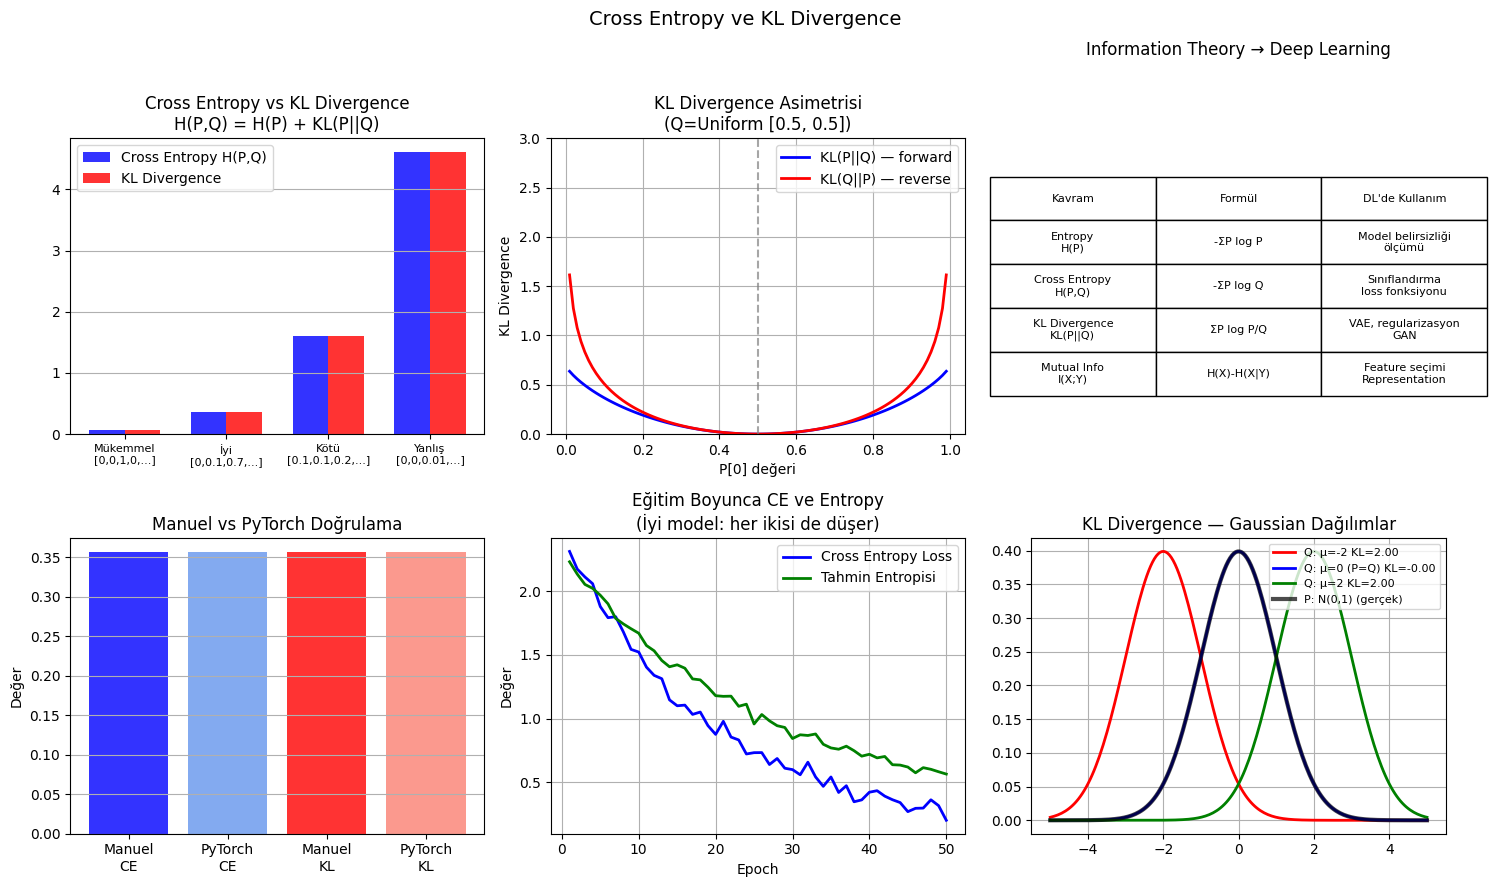

In [4]:
# CROSS ENTROPY ve KL DIVERGENCE
#
# Cross Entropy:
# H(P, Q) = -Σ P(x) * log Q(x)
# P = gerçek dağılım, Q = model tahmini
#
# KL Divergence:
# KL(P||Q) = Σ P(x) * log(P(x)/Q(x))
#           = H(P,Q) - H(P)
#
# Bağlantı:
# H(P,Q) = H(P) + KL(P||Q)
# Minimize H(P,Q) = Minimize KL(P||Q)  (H(P) sabit!)
# Bu yüzden Cross Entropy loss = KL minimizasyonu!

def cross_entropy(P, Q, eps=1e-10):
    P, Q = np.array(P), np.array(Q)
    return -np.sum(P * np.log(Q + eps))

def kl_divergence(P, Q, eps=1e-10):
    P, Q = np.array(P), np.array(Q)
    return np.sum(P * np.log((P + eps) / (Q + eps)))

# Örnek — CIFAR-10 sınıflandırma
P_gerçek = np.array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0])  # Gerçek: kedi (sınıf 2)

tahminler = {
    'Mükemmel\n[0,0,1,0,...]': np.array([0.01, 0.01, 0.94, 0.01, 0.01,
                                           0.0, 0.0, 0.01, 0.0, 0.01]),
    'İyi\n[0,0.1,0.7,...]': np.array([0.05, 0.1, 0.7, 0.05, 0.02,
                                        0.02, 0.01, 0.02, 0.02, 0.01]),
    'Kötü\n[0.1,0.1,0.2,...]': np.array([0.1, 0.1, 0.2, 0.1, 0.1,
                                           0.1, 0.05, 0.1, 0.05, 0.1]),
    'Yanlış\n[0,0,0.01,...]': np.array([0.3, 0.3, 0.01, 0.1, 0.1,
                                          0.05, 0.05, 0.05, 0.02, 0.02]),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Cross Entropy vs KL karşılaştırması
isimler = list(tahminler.keys())
ce_values = [cross_entropy(P_gerçek, Q) for Q in tahminler.values()]
kl_values = [kl_divergence(P_gerçek, Q) for Q in tahminler.values()]
h_p = entropy(P_gerçek)

x_pos = range(len(isimler))
width = 0.35
axes[0,0].bar([x - width/2 for x in x_pos], ce_values,
             width, label='Cross Entropy H(P,Q)', color='blue', alpha=0.8)
axes[0,0].bar([x + width/2 for x in x_pos], kl_values,
             width, label='KL Divergence', color='red', alpha=0.8)
axes[0,0].set_title("Cross Entropy vs KL Divergence\nH(P,Q) = H(P) + KL(P||Q)")
axes[0,0].set_xticks(x_pos)
axes[0,0].set_xticklabels(isimler, fontsize=8)
axes[0,0].legend()
axes[0,0].grid(True, axis='y')

# KL Divergence asimetrik!
print("=== KL DİVERGENCE ASİMETRİK ===")
print("KL(P||Q) ≠ KL(Q||P) — bu çok önemli!\n")

P = np.array([0.9, 0.1])
Q = np.array([0.5, 0.5])

kl_pq = kl_divergence(P, Q)
kl_qp = kl_divergence(Q, P)

print(f"P = {P}  (yanlı dağılım)")
print(f"Q = {Q}  (uniform dağılım)")
print(f"KL(P||Q) = {kl_pq:.4f}  ← P'yi Q'ya yaklaştır")
print(f"KL(Q||P) = {kl_qp:.4f}  ← Q'yu P'ye yaklaştır")
print(f"Fark: {abs(kl_pq-kl_qp):.4f}")

# Asimetri görselleştirmesi
p_values = np.linspace(0.01, 0.99, 100)
q_fixed = 0.5

kl_pq_vals = [kl_divergence([p, 1-p], [q_fixed, 1-q_fixed])
              for p in p_values]
kl_qp_vals = [kl_divergence([q_fixed, 1-q_fixed], [p, 1-p])
              for p in p_values]

axes[0,1].plot(p_values, kl_pq_vals, 'b-', linewidth=2,
              label='KL(P||Q) — forward')
axes[0,1].plot(p_values, kl_qp_vals, 'r-', linewidth=2,
              label='KL(Q||P) — reverse')
axes[0,1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.7)
axes[0,1].set_title("KL Divergence Asimetrisi\n(Q=Uniform [0.5, 0.5])")
axes[0,1].set_xlabel("P[0] değeri")
axes[0,1].set_ylabel("KL Divergence")
axes[0,1].legend()
axes[0,1].set_ylim(0, 3)
axes[0,1].grid(True)

# Cross Entropy = H(P) + KL doğrulama
print("\n=== DOĞRULAMA: H(P,Q) = H(P) + KL(P||Q) ===")
for isim, Q in tahminler.items():
    ce = cross_entropy(P_gerçek, Q)
    kl = kl_divergence(P_gerçek, Q)
    hp = entropy(P_gerçek)
    print(f"{isim.split(chr(10))[0]:12s}: CE={ce:.4f}, "
          f"H(P)={hp:.4f}, KL={kl:.4f}, "
          f"H(P)+KL={hp+kl:.4f} ✅")

# Derin öğrenmede kullanım
axes[0,2].axis('off')
tablo_data = [
    ["Kavram", "Formül", "DL'de Kullanım"],
    ["Entropy\nH(P)", "-ΣP log P", "Model belirsizliği\nölçümü"],
    ["Cross Entropy\nH(P,Q)", "-ΣP log Q", "Sınıflandırma\nloss fonksiyonu"],
    ["KL Divergence\nKL(P||Q)", "ΣP log P/Q", "VAE, regularizasyon\nGAN"],
    ["Mutual Info\nI(X;Y)", "H(X)-H(X|Y)", "Feature seçimi\nRepresentation"],
]
tablo = axes[0,2].table(
    cellText=tablo_data[1:],
    colLabels=tablo_data[0],
    loc='center', cellLoc='center'
)
tablo.scale(1.2, 2.8)
tablo.auto_set_font_size(False)
tablo.set_fontsize(8)
axes[0,2].set_title("Information Theory → Deep Learning", pad=60)

# PyTorch ile doğrula
import torch
import torch.nn.functional as F

P_torch = torch.tensor([[0.0, 0.0, 1.0, 0.0, 0.0,
                         0.0, 0.0, 0.0, 0.0, 0.0]])
Q_torch = torch.tensor([[0.05, 0.1, 0.7, 0.05, 0.02,
                         0.02, 0.01, 0.02, 0.02, 0.01]])

# PyTorch cross entropy (log_softmax kullanır)
ce_pytorch = F.cross_entropy(
    torch.log(Q_torch),
    torch.tensor([2])  # gerçek sınıf indeksi
)
ce_manuel = cross_entropy(P_gerçek,
    [0.05, 0.1, 0.7, 0.05, 0.02, 0.02, 0.01, 0.02, 0.02, 0.01])

kl_pytorch = F.kl_div(
    torch.log(Q_torch), P_torch, reduction='sum')

axes[1,0].bar(['Manuel\nCE', 'PyTorch\nCE', 'Manuel\nKL', 'PyTorch\nKL'],
             [ce_manuel, ce_pytorch.item(),
              kl_divergence(P_gerçek, [0.05,0.1,0.7,0.05,0.02,
                                        0.02,0.01,0.02,0.02,0.01]),
              kl_pytorch.item()],
             color=['blue', 'cornflowerblue', 'red', 'salmon'],
             alpha=0.8)
axes[1,0].set_title("Manuel vs PyTorch Doğrulama")
axes[1,0].set_ylabel("Değer")
axes[1,0].grid(True, axis='y')

# Eğitim boyunca CE ve entropy
np.random.seed(42)
epochs = range(1, 51)
# Simüle edilmiş eğitim
ce_train = [2.3 * np.exp(-0.05*e) + 0.1 + np.random.randn()*0.05
            for e in epochs]
entropy_pred = [2.0 * np.exp(-0.04*e) + 0.3 + np.random.randn()*0.03
               for e in epochs]

axes[1,1].plot(epochs, ce_train, 'b-', linewidth=2, label='Cross Entropy Loss')
axes[1,1].plot(epochs, entropy_pred, 'g-', linewidth=2,
              label='Tahmin Entropisi')
axes[1,1].set_title("Eğitim Boyunca CE ve Entropy\n(İyi model: her ikisi de düşer)")
axes[1,1].set_xlabel("Epoch")
axes[1,1].set_ylabel("Değer")
axes[1,1].legend()
axes[1,1].grid(True)

# KL divergence animasyonu — Gaussian
x_range = np.linspace(-5, 5, 200)
from scipy.stats import norm

axes[1,2].set_title("KL Divergence — Gaussian Dağılımlar")
P_gauss = norm.pdf(x_range, loc=0, scale=1)
for mu, renk, etiket in [(-2, 'red', 'Q: μ=-2'),
                           (0, 'blue', 'Q: μ=0 (P=Q)'),
                           (2, 'green', 'Q: μ=2')]:
    Q_gauss = norm.pdf(x_range, loc=mu, scale=1)
    kl_val = np.sum(P_gauss * np.log(P_gauss / (Q_gauss + 1e-10))) * \
             (x_range[1] - x_range[0])
    axes[1,2].plot(x_range, Q_gauss, color=renk, linewidth=2,
                  label=f'{etiket} KL={kl_val:.2f}')

axes[1,2].plot(x_range, P_gauss, 'k-', linewidth=3,
              label='P: N(0,1) (gerçek)', alpha=0.7)
axes[1,2].legend(fontsize=8)
axes[1,2].grid(True)

plt.suptitle("Cross Entropy ve KL Divergence", fontsize=14)
plt.tight_layout()
plt.show()

=== MI vs KORELASYON ===
Bağımsız                      : MI=0.390 bit, |r|=0.076
Doğrusal (r=0.9)              : MI=2.739 bit, |r|=0.994
Doğrusal olmayan (Y=X²)       : MI=1.465 bit, |r|=0.025

Dikkat: Y=X² için korelasyon ~0 ama MI yüksek!


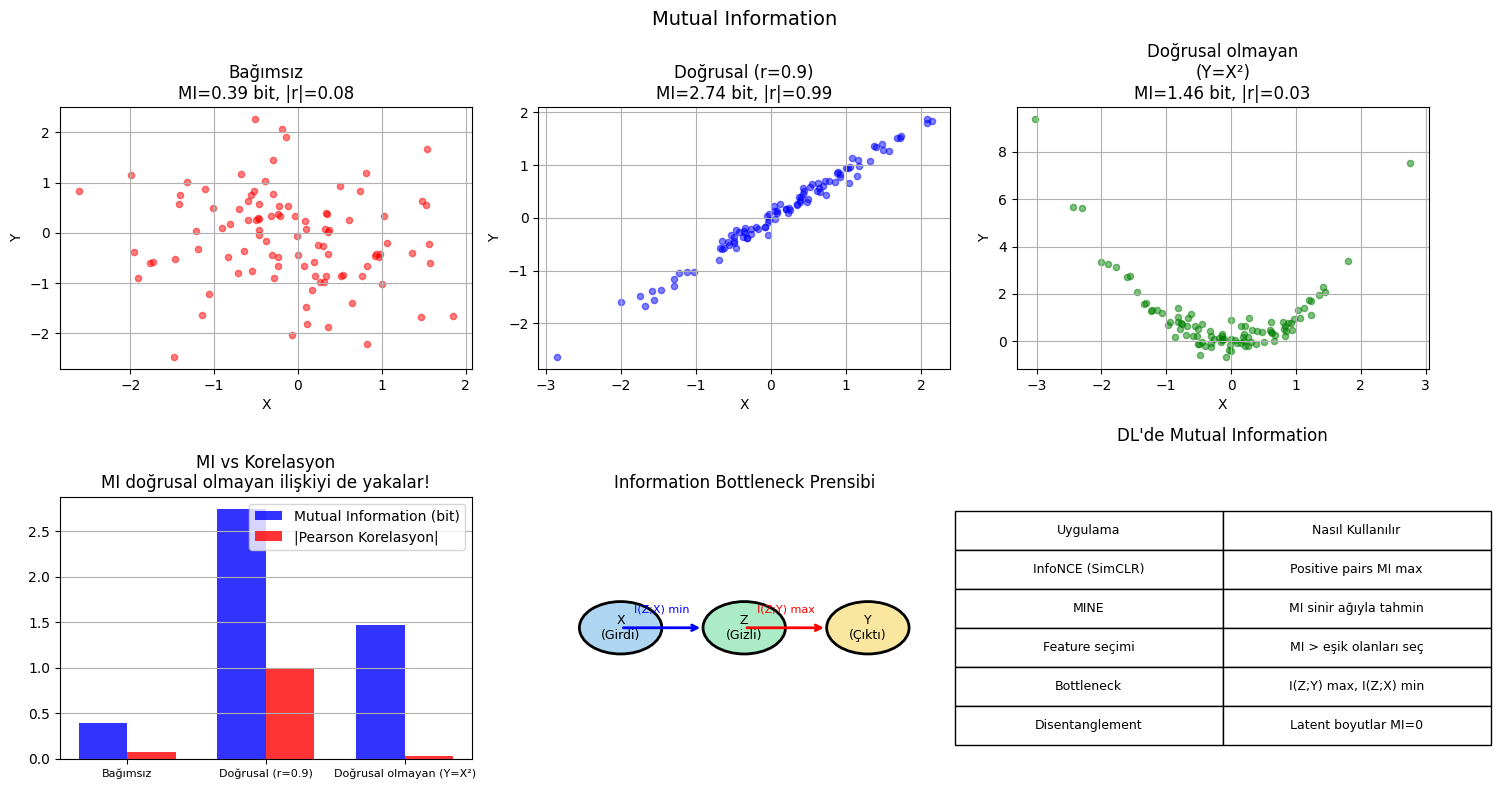

In [1]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

np.random.seed(42)
n = 500

X_ind = np.random.randn(n)
Y_ind = np.random.randn(n)

X_lin = np.random.randn(n)
Y_lin = 0.9 * X_lin + 0.1 * np.random.randn(n)

X_nonlin = np.random.randn(n)
Y_nonlin = X_nonlin**2 + 0.3 * np.random.randn(n)

def mutual_information_bins(x, y, bins=20):
    hist_xy, _, _ = np.histogram2d(x, y, bins=bins)
    hist_x, _ = np.histogram(x, bins=bins)
    hist_y, _ = np.histogram(y, bins=bins)
    p_xy = hist_xy / hist_xy.sum()
    p_x = hist_x / hist_x.sum()
    p_y = hist_y / hist_y.sum()
    mi = 0
    for i in range(bins):
        for j in range(bins):
            if p_xy[i,j] > 0 and p_x[i] > 0 and p_y[j] > 0:
                mi += p_xy[i,j] * np.log2(p_xy[i,j] / (p_x[i] * p_y[j]))
    return mi

çiftler = [
    ("Bağımsız", X_ind, Y_ind, 'red'),
    ("Doğrusal (r=0.9)", X_lin, Y_lin, 'blue'),
    ("Doğrusal olmayan\n(Y=X²)", X_nonlin, Y_nonlin, 'green'),
]

mi_values = []
corr_values = []

for i, (isim, X, Y, renk) in enumerate(çiftler):
    mi = mutual_information_bins(X, Y)
    corr, _ = pearsonr(X, Y)
    mi_values.append(mi)
    corr_values.append(abs(corr))
    axes[0, i].scatter(X[:100], Y[:100], alpha=0.5, color=renk, s=20)
    axes[0, i].set_title(f"{isim}\nMI={mi:.2f} bit, |r|={abs(corr):.2f}")
    axes[0, i].set_xlabel("X")
    axes[0, i].set_ylabel("Y")
    axes[0, i].grid(True)

isimler_mi = [c[0].replace('\n', ' ') for c in çiftler]
x_pos = range(len(isimler_mi))
width = 0.35
axes[1,0].bar([x - width/2 for x in x_pos], mi_values,
             width, label='Mutual Information (bit)', color='blue', alpha=0.8)
axes[1,0].bar([x + width/2 for x in x_pos], corr_values,
             width, label='|Pearson Korelasyon|', color='red', alpha=0.8)
axes[1,0].set_title("MI vs Korelasyon\nMI doğrusal olmayan ilişkiyi de yakalar!")
axes[1,0].set_xticks(x_pos)
axes[1,0].set_xticklabels(isimler_mi, fontsize=8)
axes[1,0].legend()
axes[1,0].grid(True, axis='y')

print("=== MI vs KORELASYON ===")
for isim, mi, corr in zip(isimler_mi, mi_values, corr_values):
    print(f"{isim:30s}: MI={mi:.3f} bit, |r|={corr:.3f}")
print("\nDikkat: Y=X² için korelasyon ~0 ama MI yüksek!")

# Information Bottleneck şeması
axes[1,1].axis('off')
axes[1,1].set_xlim(0, 5)
axes[1,1].set_ylim(0, 5)
for x, label, renk in [(0.5, 'X\n(Girdi)', '#AED6F1'),
                        (2.0, 'Z\n(Gizli)', '#ABEBC6'),
                        (3.5, 'Y\n(Çıktı)', '#F9E79F')]:
    axes[1,1].add_patch(plt.Circle((x+0.5, 2.5), 0.5,
                        facecolor=renk, edgecolor='black', linewidth=2))
    axes[1,1].text(x+0.5, 2.5, label, ha='center', va='center', fontsize=9)
axes[1,1].annotate('', xy=(2.0, 2.5), xytext=(1.0, 2.5),
                  arrowprops=dict(arrowstyle='->', color='blue', lw=2))
axes[1,1].text(1.5, 2.8, 'I(Z;X) min', ha='center', fontsize=8, color='blue')
axes[1,1].annotate('', xy=(3.5, 2.5), xytext=(2.5, 2.5),
                  arrowprops=dict(arrowstyle='->', color='red', lw=2))
axes[1,1].text(3.0, 2.8, 'I(Z;Y) max', ha='center', fontsize=8, color='red')
axes[1,1].set_title("Information Bottleneck Prensibi")

# DL'de MI kullanımı tablosu
axes[1,2].axis('off')
dl_kullanim = [
    ["Uygulama", "Nasıl Kullanılır"],
    ["InfoNCE (SimCLR)", "Positive pairs MI max"],
    ["MINE", "MI sinir ağıyla tahmin"],
    ["Feature seçimi", "MI > eşik olanları seç"],
    ["Bottleneck", "I(Z;Y) max, I(Z;X) min"],
    ["Disentanglement", "Latent boyutlar MI=0"],
]
tablo = axes[1,2].table(
    cellText=dl_kullanim[1:],
    colLabels=dl_kullanim[0],
    loc='center', cellLoc='center'
)
tablo.scale(1.3, 2.5)
tablo.auto_set_font_size(False)
tablo.set_fontsize(9)
axes[1,2].set_title("DL'de Mutual Information", pad=40)

plt.suptitle("Mutual Information", fontsize=14)
plt.tight_layout()
plt.show()